In [40]:
"""
📊 Análise Inicial de Churn de Clientes

Este script realiza a **leitura e visualização inicial** de uma base
de dados de churn de clientes utilizando as bibliotecas **Pandas**,
**Seaborn** e **Matplotlib**.

Objetivo:
- Carregar um arquivo Excel com dados de clientes
- Validar a estrutura do dataset e iniciar a análise exploratória (EDA)

Arquivo esperado:
- dados_churn_clientes.xlsx
"""

# =========================================
# 1) IMPORTS
# =========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================
# 2) PADRÃO VISUAL + FUNÇÕES UTILITÁRIAS
# =========================================
sns.set_theme(style="whitegrid")

def titulo(txt: str):
    plt.title(txt, pad=12)

def rotacionar_xticks(angulo=0):
    plt.xticks(rotation=angulo)

def show_fig():
    plt.tight_layout()
    plt.show()

def churn_rate(series_cancelou: pd.Series) -> float:
    """Retorna taxa de churn (%) onde 'Sim' é churn."""
    return series_cancelou.eq("Sim").mean() * 100

def rate_table(df: pd.DataFrame, group_col: str, target_col: str = "Cancelou") -> pd.DataFrame:
    """
    Retorna uma tabela com:
    - Total (clientes no grupo)
    - Churn_Qtd (quantidade de cancelamentos no grupo)
    - Churn_% (taxa percentual de cancelamento no grupo)
    """
    total = df.groupby(group_col)[target_col].size()
    churn_qtd = df[df[target_col] == "Sim"].groupby(group_col)[target_col].size()

    out = pd.DataFrame({"Total": total, "Churn_Qtd": churn_qtd}).fillna(0)
    out["Churn_%"] = (out["Churn_Qtd"] / out["Total"]) * 100
    return out.sort_values("Churn_%", ascending=False)

# =========================================
# 3) LEITURA DA BASE
# =========================================
df = pd.read_excel("dados_churn_clientes.xlsx")

# Visualização inicial do dataset
df.head()


,ClienteID,Idade,Sexo,Plano,MesesComoCliente,UsaSuporte,Satisfacao,Cancelou
0,1001,56,Feminino,Premium,11,Sim,3,Não
1,1002,69,Feminino,Padrão,18,Sim,1,Não
2,1003,46,Masculino,Padrão,12,Sim,5,Não
3,1004,32,Masculino,Padrão,9,Sim,5,Não
4,1005,60,Feminino,Padrão,10,Não,2,Não


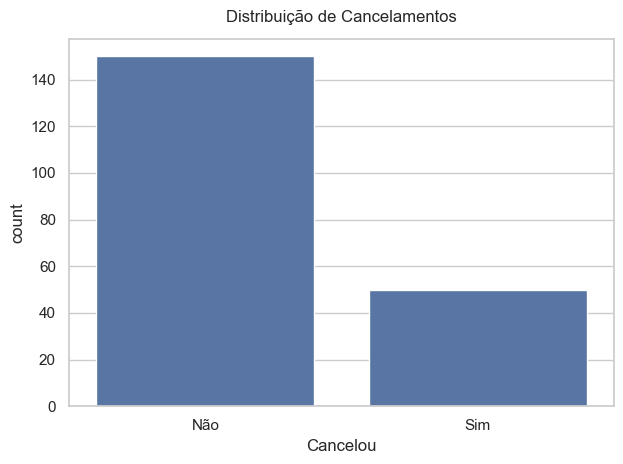

In [41]:
"""
📊 Visualização da Distribuição de Cancelamentos

Este trecho do projeto apresenta a **distribuição geral de churn**,
mostrando a quantidade de clientes que **cancelaram** e dos que
**permaneceram ativos**.

O gráfico de contagem permite uma leitura rápida do cenário
geral de retenção da base de clientes.
"""

# Gráfico de contagem para a variável de churn
sns.countplot(x="Cancelou", data=df)

# Título e exibição
titulo("Distribuição de Cancelamentos")
show_fig()


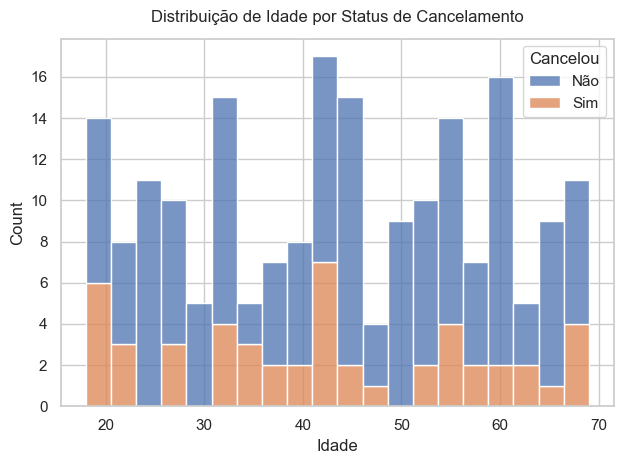

In [ ]:
"""
📊 Distribuição de Idade por Status de Cancelamento

Este trecho do projeto analisa a relação entre a **idade dos clientes**
e o **status de cancelamento (churn)**.

O histograma empilhado permite comparar visualmente a distribuição
etária entre clientes que cancelaram e os que permaneceram ativos.
"""

# Histograma da distribuição de idade segmentado por churn
sns.histplot(
    data=df,
    x="Idade",
    hue="Cancelou",
    multiple="stack",
    bins=20
)

# Título e exibição
titulo("Distribuição de Idade por Status de Cancelamento")
show_fig()


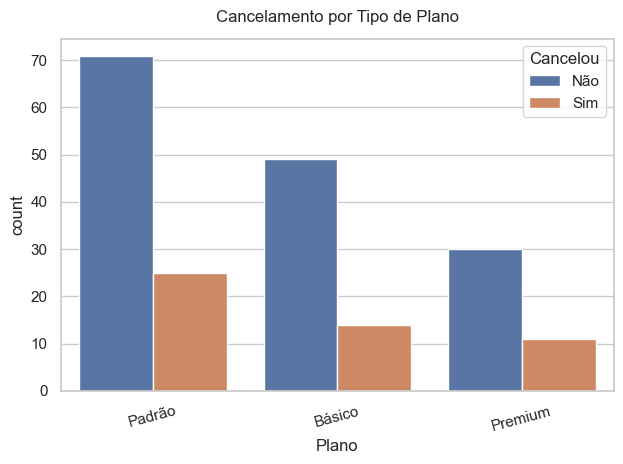

In [43]:
"""
📊 Cancelamento por Tipo de Plano

Este trecho do projeto analisa a relação entre o **tipo de plano**
contratado pelos clientes e o **status de cancelamento (churn)**.

O gráfico de contagem permite comparar, para cada plano,
a quantidade de clientes que cancelaram e os que permaneceram ativos.
"""

# Ordena planos por volume total (opcional, mas recomendado)
ordem_planos = df["Plano"].value_counts().index

# Gráfico de contagem de cancelamento por tipo de plano
sns.countplot(
    x="Plano",
    hue="Cancelou",
    data=df,
    order=ordem_planos
)

# Título e exibição
titulo("Cancelamento por Tipo de Plano")
rotacionar_xticks(15)
show_fig()


In [44]:
"""
📊 Taxa Percentual de Cancelamento por Tipo de Plano

Este trecho do projeto apresenta a **taxa de churn (%) para cada tipo
de plano**, permitindo comparar planos independentemente do volume
total de clientes.

A análise ajuda a identificar planos com maior risco de cancelamento.
"""

# Tabela de taxa de churn por plano
tab_plano = rate_table(df, "Plano")

# Exibição ordenada por maior taxa de churn
tab_plano[["Total", "Churn_%"]].round(2)


,Total,Churn_%
Plano,,
Premium,41,26.83
Padrão,96,26.04
Básico,63,22.22


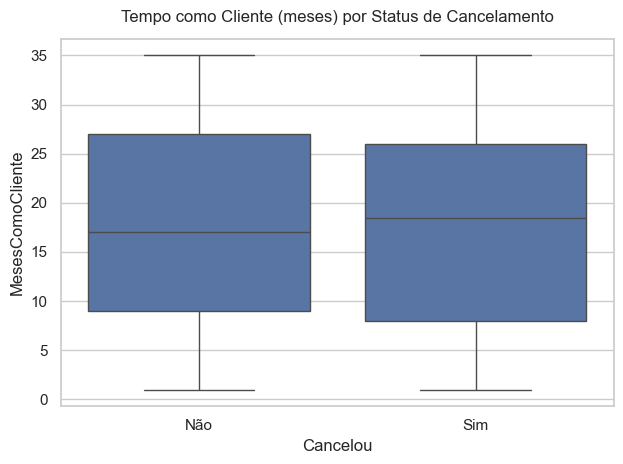

In [45]:
"""
📊 Tempo como Cliente por Status de Cancelamento

Este trecho do projeto analisa a relação entre o **tempo de permanência
do cliente** (em meses) e o **status de cancelamento (churn)**.

O boxplot permite visualizar:
- Mediana do tempo como cliente
- Dispersão dos dados
- Possíveis outliers
- Diferença de comportamento entre clientes que cancelaram
  e os que permaneceram ativos
"""

# Boxplot do tempo como cliente segmentado por status de cancelamento
sns.boxplot(
    x="Cancelou",
    y="MesesComoCliente",
    data=df
)

# Título e exibição
titulo("Tempo como Cliente (meses) por Status de Cancelamento")
show_fig()


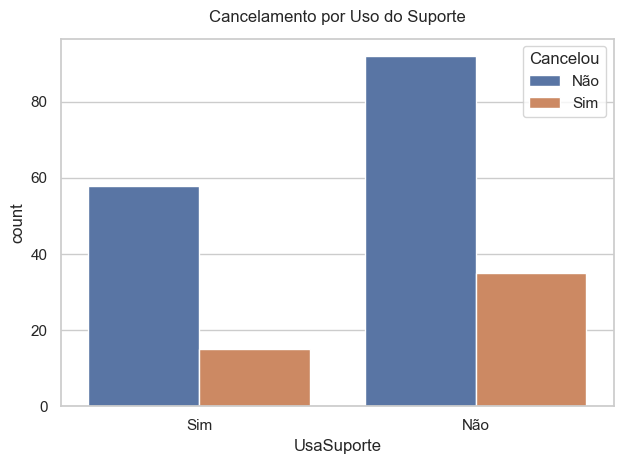

In [46]:
"""
📊 Cancelamento por Uso do Suporte

Este trecho do projeto analisa a relação entre o **uso do suporte**
pelos clientes e o **status de cancelamento (churn)**.

O objetivo é identificar se clientes que acionam o suporte apresentam
maior propensão ao cancelamento, indicando possíveis falhas na
experiência do cliente ou oportunidades de melhoria no atendimento.
"""

# Gráfico de contagem de cancelamento por uso do suporte
sns.countplot(
    x="UsaSuporte",
    hue="Cancelou",
    data=df
)

# Título e exibição
titulo("Cancelamento por Uso do Suporte")
show_fig()


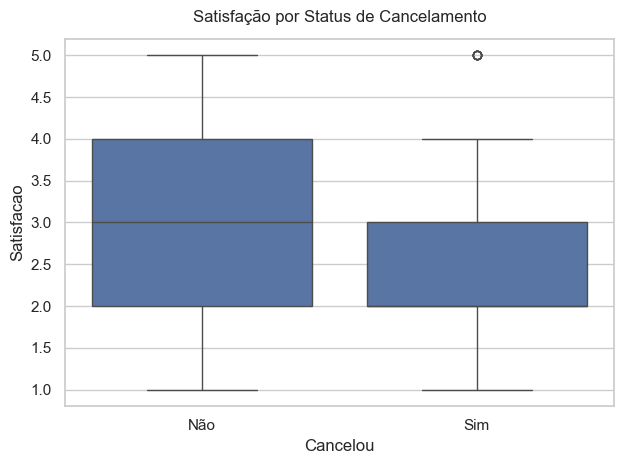

In [47]:
"""
📊 Satisfação por Status de Cancelamento

Este trecho do projeto analisa a relação entre o **nível de satisfação
do cliente** e o **status de cancelamento (churn)**.

O boxplot permite identificar:
- Diferenças na satisfação entre clientes que cancelaram
  e os que permaneceram ativos
- Dispersão dos níveis de satisfação
- Possíveis outliers
- Indícios de associação entre insatisfação e churn
"""

# Boxplot da satisfação segmentada por status de cancelamento
sns.boxplot(
    x="Cancelou",
    y="Satisfacao",
    data=df
)

# Título e exibição
titulo("Satisfação por Status de Cancelamento")
show_fig()


In [49]:
"""
📊 Taxa Geral de Cancelamento (Churn)

Este trecho do projeto calcula a **taxa geral de churn da base de clientes**,
mostrando a proporção percentual de clientes que **cancelaram** e dos que
**permaneceram ativos**.

O cálculo é feito a partir da normalização da coluna `Cancelou`, permitindo
entender rapidamente o nível de retenção da empresa.

O resultado é apresentado em **percentual (%)**, facilitando a leitura
e a interpretação dos dados.
"""

(df["Cancelou"].value_counts(normalize=True) * 100).round(2)


Cancelou
Não    75.0
Sim    25.0
Name: proportion, dtype: float64

In [50]:
"""
📊 Resumo Final das Métricas de Churn
"""

resumo = {
    "Churn Geral (%)": round(churn_rate(df["Cancelou"]), 2),
    "Plano com maior churn (%)": rate_table(df, "Plano").index[0],
    "Faixa etária mais crítica": rate_table(df, "FaixaEtaria").index[0] if "FaixaEtaria" in df.columns else "N/A",
    "Satisfação média (cancelou)": round(df[df["Cancelou"]=="Sim"]["Satisfacao"].mean(), 2),
    "Satisfação média (ativo)": round(df[df["Cancelou"]=="Não"]["Satisfacao"].mean(), 2),
}

pd.DataFrame.from_dict(resumo, orient="index", columns=["Valor"])


,Valor
Churn Geral (%),25.0
Plano com maior churn (%),Premium
Faixa etária mais crítica,N/A
Satisfação média (cancelou),2.62
Satisfação média (ativo),3.03
